In [19]:
import os
import torch
from torch.utils.data import DataLoader
from dataset.dataloader import BrainDataset_WTonly_recur,HDF5BrainDataset_loadall,HDF5BrainDataset
import tqdm
import os
import torch
import h5py
import numpy as np

base_path ='/Users/yifanli/Desktop/dataset/GBM_public/procesed_perfect_week0'

# Initialize lists for each modality and labels
flair_paths = []
t1_paths = []
t1gd_paths = []
t2_paths = []
label_paths = []

# Initialize a dictionary to track label availability
label_availability = {}

# Loop through each patient folder
for patient_folder in os.listdir(base_path):
    patient_path = os.path.join(base_path, patient_folder)
    
    if os.path.isdir(patient_path):
        # Reset or declare label found flag for each patient
        label_found = False
        
        for file in os.listdir(patient_path):
            file_path = os.path.join(patient_path, file)

            if file.endswith('FLAIR.nii.gz'):
                flair_paths.append(file_path)
            elif file.endswith('_T1.nii.gz'):
                t1_paths.append(file_path)
            elif file.endswith('_CT1.nii.gz'):
                t1gd_paths.append(file_path)
            elif file.endswith('_T2.nii.gz'):
                t2_paths.append(file_path)
            elif file.endswith('_T2_mask.nii.gz'):
                label_paths.append(file_path)
 
print(f'FLAIR files: {len(flair_paths)}')
print(f'T1 files: {len(t1_paths)}')
print(f'T1Gd files: {len(t1gd_paths)}')
print(f'T2 files: {len(t2_paths)}')
print(f'Label files: {len(label_paths)}')

FLAIR files: 31
T1 files: 31
T1Gd files: 31
T2 files: 31
Label files: 31


In [2]:
# Function to optimize data types and save as HDF5
def save_to_hdf5(group, data):
    if isinstance(data, dict):
        for key, value in data.items():
            if isinstance(value, np.ndarray):
                # Save numpy arrays directly as datasets
                array = value
                if array.dtype == np.float64:
                    array = array.astype(np.float32)
                elif array.dtype == np.int64:
                    array = array.astype(np.int32)
                group.create_dataset(key, data=array, compression='gzip', compression_opts=9)
            elif isinstance(value, (np.number, float, int, str, bytes)):
                # Save basic data types as attributes
                group.attrs[key] = value
            else:
                # Recursively save nested structures
                subgroup = group.create_group(str(key))
                save_to_hdf5(subgroup, value)
    elif isinstance(data, (list, tuple)):
        # Handle lists and tuples
        for idx, item in enumerate(data):
            item_name = f'item_{idx}'
            if isinstance(item, np.ndarray):
                array = item
                if array.dtype == np.float64:
                    array = array.astype(np.float32)
                elif array.dtype == np.int64:
                    array = array.astype(np.int32)
                group.create_dataset(
                    item_name, data=array, compression='gzip', compression_opts=9
                )
            elif isinstance(item, (np.number, float, int, str, bytes)):
                group.attrs[item_name] = item
            else:
                subgroup = group.create_group(item_name)
                save_to_hdf5(subgroup, item)
    elif isinstance(data, np.ndarray):
        # Save numpy arrays
        array = data
        if array.dtype == np.float64:
            array = array.astype(np.float32)
        elif array.dtype == np.int64:
            array = array.astype(np.int32)
        group.create_dataset('data', data=array, compression='gzip', compression_opts=9)
    elif isinstance(data, (np.number, float, int, str, bytes)):
        # Save basic data types as attributes
        group.attrs['value'] = data
    else:
        # Convert unsupported types to string
        group.attrs['value'] = str(data)

def convert_pt_to_h5(pt_file_path, h5_file_path,only_cts = False):
    # Load the data from the .pt file
    data = torch.load(pt_file_path)
    if only_cts:
        if 'cts' in data:
            data = {'cts': data['cts']}
    with h5py.File(h5_file_path, 'w') as hf:
        save_to_hdf5(hf, data)
def convert_pt_to_h5_v2(data, h5_file_path,only_cts = False):
    if only_cts:
        if 'cts' in data:
            data = {'cts': data['cts']}
    with h5py.File(h5_file_path, 'w') as hf:
        save_to_hdf5(hf, data)

In [21]:
# Initialize your dataset
train_dataset = BrainDataset_WTonly_recur(
    t1_paths=t1_paths,
    t1gd_paths=t1gd_paths,
    t2_paths=t2_paths,
    flair_paths=flair_paths,
    label_paths=label_paths,
    is_train=True)

In [4]:
# New directory to save compressed .h5 files
h5_data_dir = '/Users/yifanli/Desktop/dataset/GBM_public/perfect_h5'
if not os.path.exists(h5_data_dir):
    os.makedirs(h5_data_dir)
    
    
for idx in tqdm.tqdm(range(len(train_dataset))):
    name = t1_paths[idx].split('/')[-2].replace("-", "_")

    data_filename_h5 = os.path.join(h5_data_dir, f'{name}.h5')
#     if os.path.exists( data_filename):
#         print(f'Skipping, {data_filename_h5} already exists.')
#         continue  # Skip to the next file
    data = train_dataset[idx]
#     torch.save(data, data_filename)
    convert_pt_to_h5_v2(data, data_filename_h5 ,only_cts=False)


100%|███████████████████████████████████████████| 31/31 [36:48<00:00, 71.24s/it]


In [5]:
from models.CKD_model import CKD,CKD_encoder_only
model = CKD_encoder_only(embed_dim=32, output_dim=3, img_size=(128, 128, 128), patch_size=(4, 4, 4), in_chans=1, depths=[2, 2, 2], num_heads=[2, 4, 8, 16], window_size=(7, 7, 7), mlp_ratio=4.)
model.load_state_dict(torch.load("/Users/yifanli/Desktop/P3SOTA/CKD-TransBTS-main/best_model_BraTs.pkl", map_location='cpu'))
model.eval()
print()


/opt/anaconda3/lib/python3.8/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3484.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [6]:
current_h5_data_dir =  'perfect_h5'
dataset = HDF5BrainDataset(current_h5_data_dir)
for ele in dataset:
    break
    
# 3. Define a desired batch size
batch_size = 2

# 4. Containers to hold data while batching
batch_imgs = []     # will hold NumPy arrays of shape [4, D, H, W]
batch_files = []    # will hold paths/identifiers

# 5. Loop through patient files
for index, ele in tqdm.tqdm(enumerate(dataset)):
    # Extract and stack the modalities (shape [4, D, H, W])
    patient_image = np.stack([
        ele['img']['t1'],
        ele['img']['t1gd'],
        ele['img']['t2'],
        ele['img']['flair_data']
    ], axis=0)

    # Append to our batch lists
    batch_imgs.append(patient_image)
    batch_files.append(index)

    # If we've reached the desired batch size, process them
    if len(batch_imgs) == batch_size:
        # Convert the list of [4, D, H, W] images to a float32 Tensor [B, 4, D, H, W]
        batch_tensor = torch.from_numpy(np.array(batch_imgs, dtype=np.float32))
        
        with torch.no_grad():
            # Get embeddings from model
            embeddings = model(batch_tensor)

        # Save embeddings back into each file
        for i, index_ in enumerate(batch_files):
            dataset.save_img_embedding(index_, embeddings[i].cpu().numpy())

        # Reset batch storage
        batch_imgs = []
        batch_files = []

# 6. Handle any leftover files if the total number is not divisible by batch_size
if len(batch_imgs) > 0:
    batch_tensor = torch.from_numpy(np.array(batch_imgs, dtype=np.float32))
    with torch.no_grad():
        embeddings = model(batch_tensor)
    for i, index_ in enumerate(batch_files):
        dataset.save_img_embedding(index_, embeddings[i].cpu().numpy())

31it [04:56,  9.58s/it]


In [7]:
from torch.utils.data import Subset, ConcatDataset
from dataset.dataloader import HDF5BrainDataset_loadall
# Initialize the dataset

h5_data_dir = 'perfect_h5'

# Create dataset instances from the directories.
dataset = HDF5BrainDataset_loadall(h5_data_dir)
data_loader =DataLoader(dataset, batch_size=1)
for ele in data_loader:
    print(ele.keys())
    break

dict_keys(['patient_idx', 'bound', 'center', 'center_pre', 'cts', 'img', 'img_embedding'])


#   Process another folder

In [28]:
import os
import torch
from torch.utils.data import DataLoader
from dataset.dataloader import BrainDataset_WTonly
import tqdm
import os
import torch
import h5py
import numpy as np

base_path ='/Users/yifanli/Desktop/dataset/GBM_public/procesed_trainOnly_week0'

# Initialize lists for each modality and labels
flair_paths = []
t1_paths = []
t1gd_paths = []
t2_paths = []
label_paths = []

# Initialize a dictionary to track label availability
label_availability = {}

# Loop through each patient folder
for patient_folder in os.listdir(base_path):
    patient_path = os.path.join(base_path, patient_folder)
    
    if os.path.isdir(patient_path):
        # Reset or declare label found flag for each patient
        label_found = False
        
        for file in os.listdir(patient_path):
            file_path = os.path.join(patient_path, file)

            if file.endswith('FLAIR.nii.gz'):
                flair_paths.append(file_path)
            elif file.endswith('_T1.nii.gz'):
                t1_paths.append(file_path)
            elif file.endswith('_CT1.nii.gz'):
                t1gd_paths.append(file_path)
            elif file.endswith('_T2.nii.gz'):
                t2_paths.append(file_path)
            elif file.endswith('_T2_mask.nii.gz'):
                label_paths.append(file_path)
 
print(f'FLAIR files: {len(flair_paths)}')
print(f'T1 files: {len(t1_paths)}')
print(f'T1Gd files: {len(t1gd_paths)}')
print(f'T2 files: {len(t2_paths)}')
print(f'Label files: {len(label_paths)}')

FLAIR files: 14
T1 files: 14
T1Gd files: 14
T2 files: 14
Label files: 14


In [29]:
# Initialize your dataset
train_dataset = BrainDataset_WTonly_recur(
    t1_paths=t1_paths,
    t1gd_paths=t1gd_paths,
    t2_paths=t2_paths,
    flair_paths=flair_paths,
    label_paths=label_paths,
    is_train=True)

In [30]:
# New directory to save compressed .h5 files
h5_data_dir = '/Users/yifanli/Desktop/dataset/GBM_public/trainOnly_h5'
if not os.path.exists(h5_data_dir):
    os.makedirs(h5_data_dir)
    
    
for idx in tqdm.tqdm(range(len(train_dataset))):

    name = t1_paths[idx].split('/')[-2].replace("-", "_")
    data_filename_h5 = os.path.join(h5_data_dir, f'{name}.h5')
#     if os.path.exists( data_filename):
#         print(f'Skipping, {data_filename_h5} already exists.')
#         continue  # Skip to the next file
    data = train_dataset[idx]
#     torch.save(data, data_filename)
    convert_pt_to_h5_v2(data, data_filename_h5 ,only_cts=False)

100%|██████████████████████████████████████████| 14/14 [00:00<00:00, 332.08it/s]


In [12]:
current_h5_data_dir =  'trainOnly_h5'
dataset = HDF5BrainDataset(current_h5_data_dir)
for ele in dataset:
    break
    
# 3. Define a desired batch size
batch_size = 2

# 4. Containers to hold data while batching
batch_imgs = []     # will hold NumPy arrays of shape [4, D, H, W]
batch_files = []    # will hold paths/identifiers

# 5. Loop through patient files
for index, ele in tqdm.tqdm(enumerate(dataset)):
    # Extract and stack the modalities (shape [4, D, H, W])
    patient_image = np.stack([
        ele['img']['t1'],
        ele['img']['t1gd'],
        ele['img']['t2'],
        ele['img']['flair_data']
    ], axis=0)

    # Append to our batch lists
    batch_imgs.append(patient_image)
    batch_files.append(index)

    # If we've reached the desired batch size, process them
    if len(batch_imgs) == batch_size:
        # Convert the list of [4, D, H, W] images to a float32 Tensor [B, 4, D, H, W]
        batch_tensor = torch.from_numpy(np.array(batch_imgs, dtype=np.float32))
        
        with torch.no_grad():
            # Get embeddings from model
            embeddings = model(batch_tensor)

        # Save embeddings back into each file
        for i, index_ in enumerate(batch_files):
            dataset.save_img_embedding(index_, embeddings[i].cpu().numpy())

        # Reset batch storage
        batch_imgs = []
        batch_files = []

# 6. Handle any leftover files if the total number is not divisible by batch_size
if len(batch_imgs) > 0:
    batch_tensor = torch.from_numpy(np.array(batch_imgs, dtype=np.float32))
    with torch.no_grad():
        embeddings = model(batch_tensor)
    for i, index_ in enumerate(batch_files):
        dataset.save_img_embedding(index_, embeddings[i].cpu().numpy())

14it [02:18,  9.89s/it]


/var/folders/8y/nr_3h7gj0g51qdfkp3k2j3zw0000gn/T/ipykernel_29172/3179356623.py:95: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  red_marker.set_data(frame, current_lik)


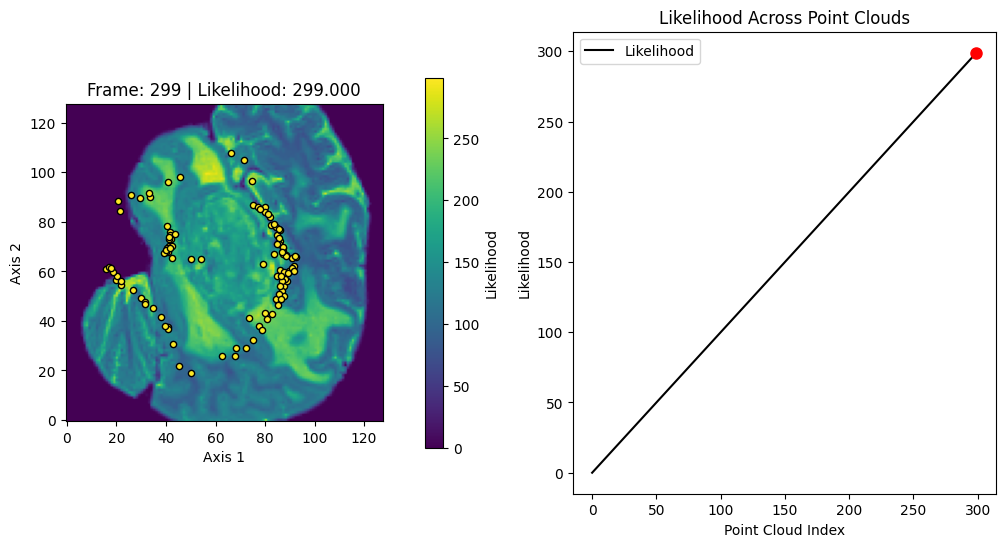

In [24]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# -----------------------------
# Data Preparation
# -----------------------------
# Assuming val_item is already loaded.
# point_clouds shape: (300, 4096, 3)
point_clouds = ele['cts']['TC_l']['item_0']
# likelihoods provided as p_tumor_cos (convert to a NumPy array if needed)
likelihoods = np.arange(300)

# -----------------------------
# Define the Slicing Plane for the Point Cloud
# -----------------------------
# For a slice cut on the point cloud only, choose a fixed x-coordinate.
# Here, we take the median of all x-values from the point clouds.
slice_val = 60
tol = 0.5  # Tolerance: points with |x - slice_val| < tol will be included
# Use this value (rounded) as the slice index for the T1 image background.
slice_index = int(np.round(slice_val))
t1_image = ele['img']['t2']
t1_slice = t1_image[slice_val, :, :]  # 2D background image


# -----------------------------
# Setup Colormap Based on Likelihood
# -----------------------------
norm = plt.Normalize(vmin=likelihoods.min(), vmax=likelihoods.max())
cmap = plt.cm.viridis

# -----------------------------
# Setup Figure for Animation
# -----------------------------
fig = plt.figure(figsize=(12, 6))

# Left subplot: for the point cloud slice (2D view)
ax_pc = fig.add_subplot(121)
# Right subplot: for the likelihood curve
ax_lik = fig.add_subplot(122)

# Plot the overall likelihood curve on the right subplot
ax_lik.plot(np.arange(300), likelihoods, 'k-', label='Likelihood')
red_marker, = ax_lik.plot([0], [likelihoods[0]], 'ro', markersize=8)
ax_lik.set_title('Likelihood Across Point Clouds')
ax_lik.set_xlabel('Point Cloud Index')
ax_lik.set_ylabel('Likelihood')
ax_lik.legend()

# Create a ScalarMappable for the colorbar on the left subplot
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax_pc, shrink=0.8, pad=0.1)
cbar.set_label('Likelihood')

# Set initial labels and limits for the left subplot (2D view)
ax_pc.set_xlabel('Axis 1')
ax_pc.set_ylabel('Axis 2')
# ax_pc.set_xlim(60, 120)  # approximate range for axis 1
# ax_pc.set_ylim(30, 90)   # approximate range for axis 2

# -----------------------------
# Animation Update Function
# -----------------------------
def update(frame):
    # Clear the left subplot and reapply labels/limits
    
    ax_pc.clear()
    ax_pc.set_xlabel('Axis 1')
    ax_pc.set_ylabel('Axis 2')
#     ax_pc.set_xlim(60, 120)
#     ax_pc.set_ylim(30, 90)
    
    # Get current point cloud and its likelihood
    ax_pc.imshow(t1_slice, origin='lower')
    pc = point_clouds[frame]
    current_lik = likelihoods[frame]
    
    # Filter points near the slicing plane (using x-coordinate)
    mask = np.abs(pc[:, 0] - slice_val) < tol
    slice_points = pc[mask]
    
    # Map the current likelihood to a color using the gradient colormap
    color = cmap(norm(current_lik))
    
    # Plot the filtered points (using axis 1 and 2 as coordinates)
    if slice_points.size > 0:
        ax_pc.scatter(slice_points[:, 2], slice_points[:, 1],
                      c=[color], s=20, edgecolors='k')
    
    ax_pc.set_title(f'Frame: {frame} | Likelihood: {current_lik:.3f}')
    
    # Update the red marker on the likelihood curve
    red_marker.set_data(frame, current_lik)
    
    return ax_pc, red_marker

# -----------------------------
# Create and Save the Animation as a GIF
# -----------------------------
ani = animation.FuncAnimation(fig, update, frames=300, interval=200, blit=False)
ani.save('point_cloud_slice_only_bac.gif', writer='pillow', fps=5)

plt.show()
